In [ ]:
from pathlib import Path
import sys


here = Path.cwd()
candidates = [here] + list(here.parents)
for p in candidates:
    if (p / "Code").is_dir():
        sys.path.insert(0, str(p))
        break
else:
    raise RuntimeError("Couldn't find a 'Code' folder in this project.")



import autograd.numpy as np
import matplotlib.pyplot as plt

from Code.ffnn2 import NeuralNetwork as FFNN 
from Code.scheduler import Adam, RMS_prop, Constant
from Code.activations import sigmoid, identity, derivate 
from Code.data import runge_function, make_data
from Code.cost import CostOLS, dCostOLS
from Code.comparison import run_comparison
from Code.plot import plot_sweep_heatmap
from Code.helpers import train_eval_once_with_pred


import pandas as pd
import seaborn as sns 

sns.set_theme(style="white", font_scale=1.3)
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["figure.dpi"] = 200
plt.rcParams.update({
    "savefig.dpi": 200,
    "savefig.bbox": "tight"
})


In [2]:
#Initialize data

(seed_fixed,
 rng_fixed,
 X_fixed_test,
 y_fixed_test,
 N,
 rng,
 x,
 noise,
 y,
 X_train,
 X_val,
 y_train,
 y_val,
 scaler,
 X_train_scaled,
 X_val_scaled,
 X_fixed_test_scaled) = make_data(seed_fixed=42, N=200, noise_std=0.1, test_N=2000)



# Part b

### One (50 nodes) and two hidden layers (50, 100 nodes), with different optimizers (Plain GD, SGD, SGD with Adam, SGD with RMSProp). 

In [3]:
"""Parameters for comparisons and sweeps"""
input_nodes = X_train_scaled.shape[1] 
output_nodes = 1
lam = 0.0
hidden_nodes1 = 50
hidden_nodes2 = 100

# Architecture 1: One Hidden Layer (50 nodes) 
layer_sizes_1H = [hidden_nodes1, output_nodes]

# Architecture 2: Two Hidden Layers (50 and 100 nodes)
layer_sizes_2H = [hidden_nodes1, hidden_nodes2, output_nodes]

eta_base = 0.01 
rho_val = 0.9      # Recommended rho for RMSprop/Adam 
rho2_val = 0.999   # Recommended rho2 for Adam 

# Optimizers to sweep
optimizers_to_sweep = {
    'GD': (Constant, {}),
    'SGD': (Constant, {}),
    'RMS_prop': (RMS_prop, {'rho': rho_val}),
    'Adam': (Adam, {'rho': rho_val, 'rho2': rho2_val})
}
eta_vals = np.logspace(-5, -1, 5) # Sweep 5 values
epochs_sweep = 500 #reasonable epoch value from N_test.ipynb



### Sweep over hyperparameters/architecture: 

In [4]:
all_sweep_results = {}

# Architectures (layers and nodes) to sweep
architectures_to_sweep = {
    '1_Hidden_Layer (50)': layer_sizes_1H,
    '2_Hidden_Layers (50, 100)': layer_sizes_2H
}


# hyperparameter sweep 
# Iterate over architectures
for arch_name, layer_sizes in architectures_to_sweep.items():
    print(f"\n================ {arch_name} ================")
    arch_scores = {}

    # Iterate over optimizers
    for opt_name, (optimizer_class, fixed_params) in optimizers_to_sweep.items():
        print(f"--- Optimizer {opt_name} ---")
        mse_scores_for_eta = []
        
        # Iterate over eta values
        for eta in eta_vals:
            # Prepare kwargs for the current run
            current_kwargs = {'eta': eta}
            current_kwargs.update(fixed_params)
            fit_kwargs = {'eta': eta, **fixed_params}

            if opt_name == 'GD':
                fit_kwargs['batches'] = 1
            
            # Run comparison using the defined architecture
            scores, nn = run_comparison(
                optimizer_class,
                X_train_scaled, 
                y_train,
                network_input_size=input_nodes,
                layer_output_sizes=layer_sizes,
                epochs=epochs_sweep,  
                lam=lam,
                **current_kwargs
            )
            
            y_pred_test = nn.predict(X_fixed_test_scaled) 

            # Get the final mse
            final_mse   = CostOLS(y_pred_test, y_fixed_test)
            mse_scores_for_eta.append(final_mse)
            print(f"  {opt_name} (eta={eta:.1e}): MSE={final_mse:.6f}")
        
        arch_scores[opt_name] = mse_scores_for_eta

    all_sweep_results[arch_name] = arch_scores


================ 1_Hidden_Layer (50) ================
--- Optimizer GD ---
  GD (eta=1.0e-05): MSE=0.143846
  GD (eta=1.0e-04): MSE=0.094550
  GD (eta=1.0e-03): MSE=0.094280
  GD (eta=1.0e-02): MSE=0.094417
  GD (eta=1.0e-01): MSE=0.095337
--- Optimizer SGD ---
  SGD (eta=1.0e-05): MSE=0.143846
  SGD (eta=1.0e-04): MSE=0.094550
  SGD (eta=1.0e-03): MSE=0.094280
  SGD (eta=1.0e-02): MSE=0.094417
  SGD (eta=1.0e-01): MSE=0.095337
--- Optimizer RMS_prop ---
  RMS_prop (eta=1.0e-05): MSE=0.094388
  RMS_prop (eta=1.0e-04): MSE=0.094364
  RMS_prop (eta=1.0e-03): MSE=0.094970
  RMS_prop (eta=1.0e-02): MSE=0.012733
  RMS_prop (eta=1.0e-01): MSE=0.098695
--- Optimizer Adam ---
  Adam (eta=1.0e-05): MSE=0.114113
  Adam (eta=1.0e-04): MSE=0.094325
  Adam (eta=1.0e-03): MSE=0.094721
  Adam (eta=1.0e-02): MSE=0.013035
  Adam (eta=1.0e-01): MSE=0.094722

================ 2_Hidden_Layers (50, 100) ================
--- Optimizer GD ---
  GD (eta=1.0e-05): MSE=0.112589
  GD (eta=1.0e-04): MSE=0.094275

### Visualization

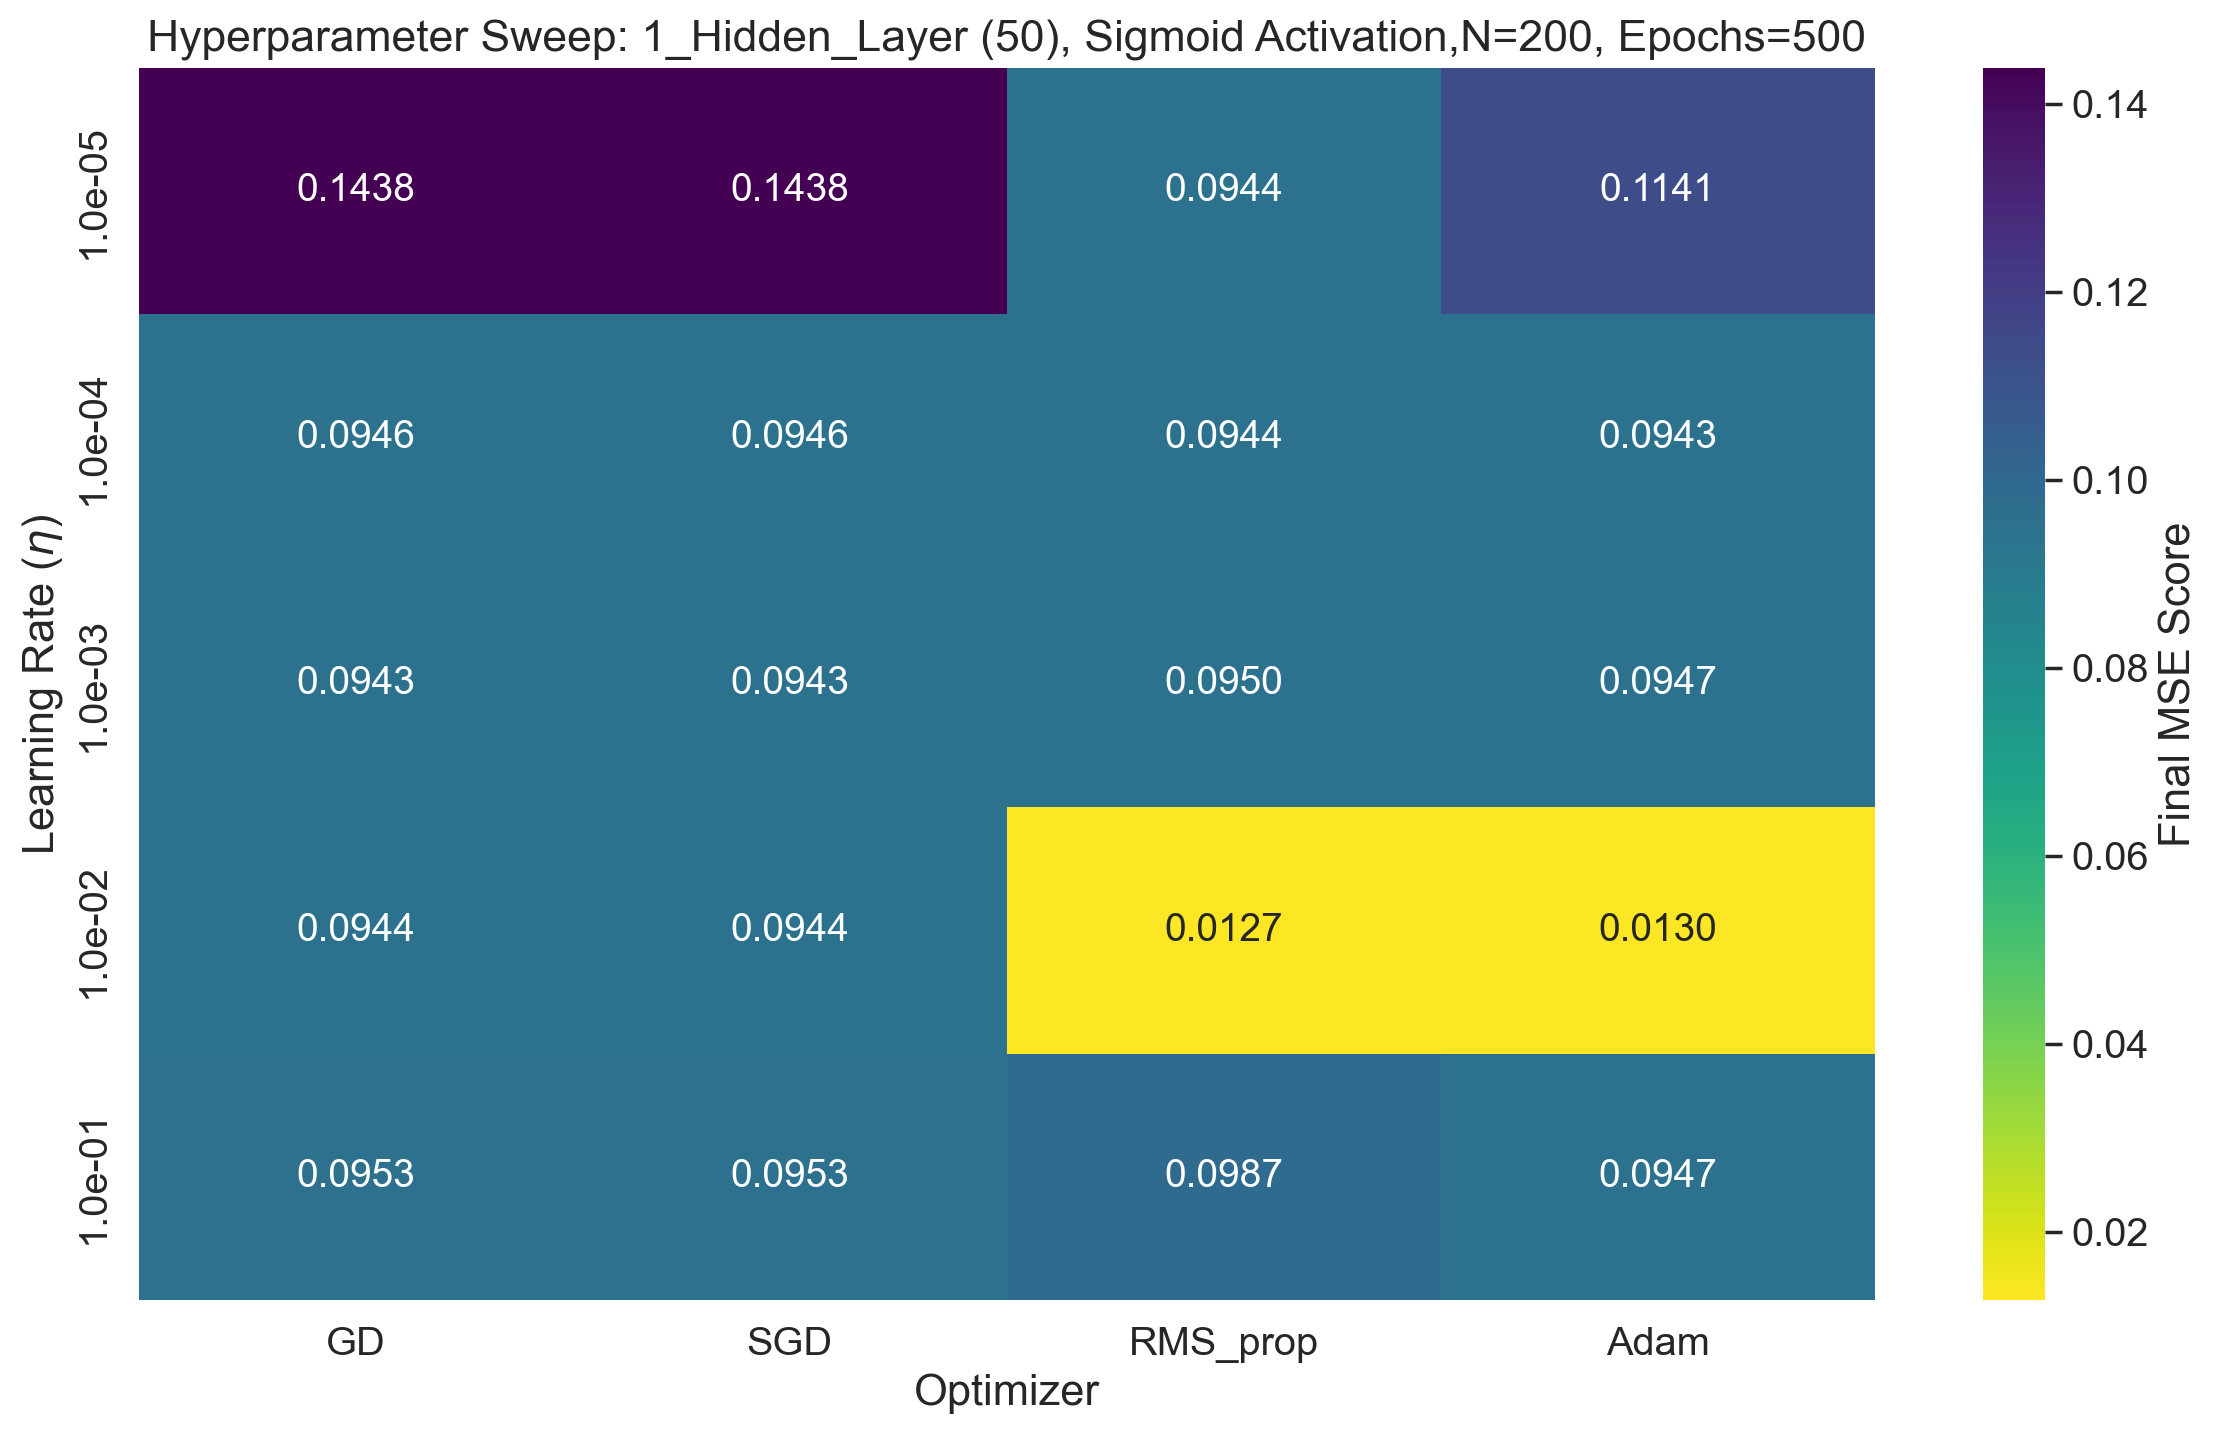

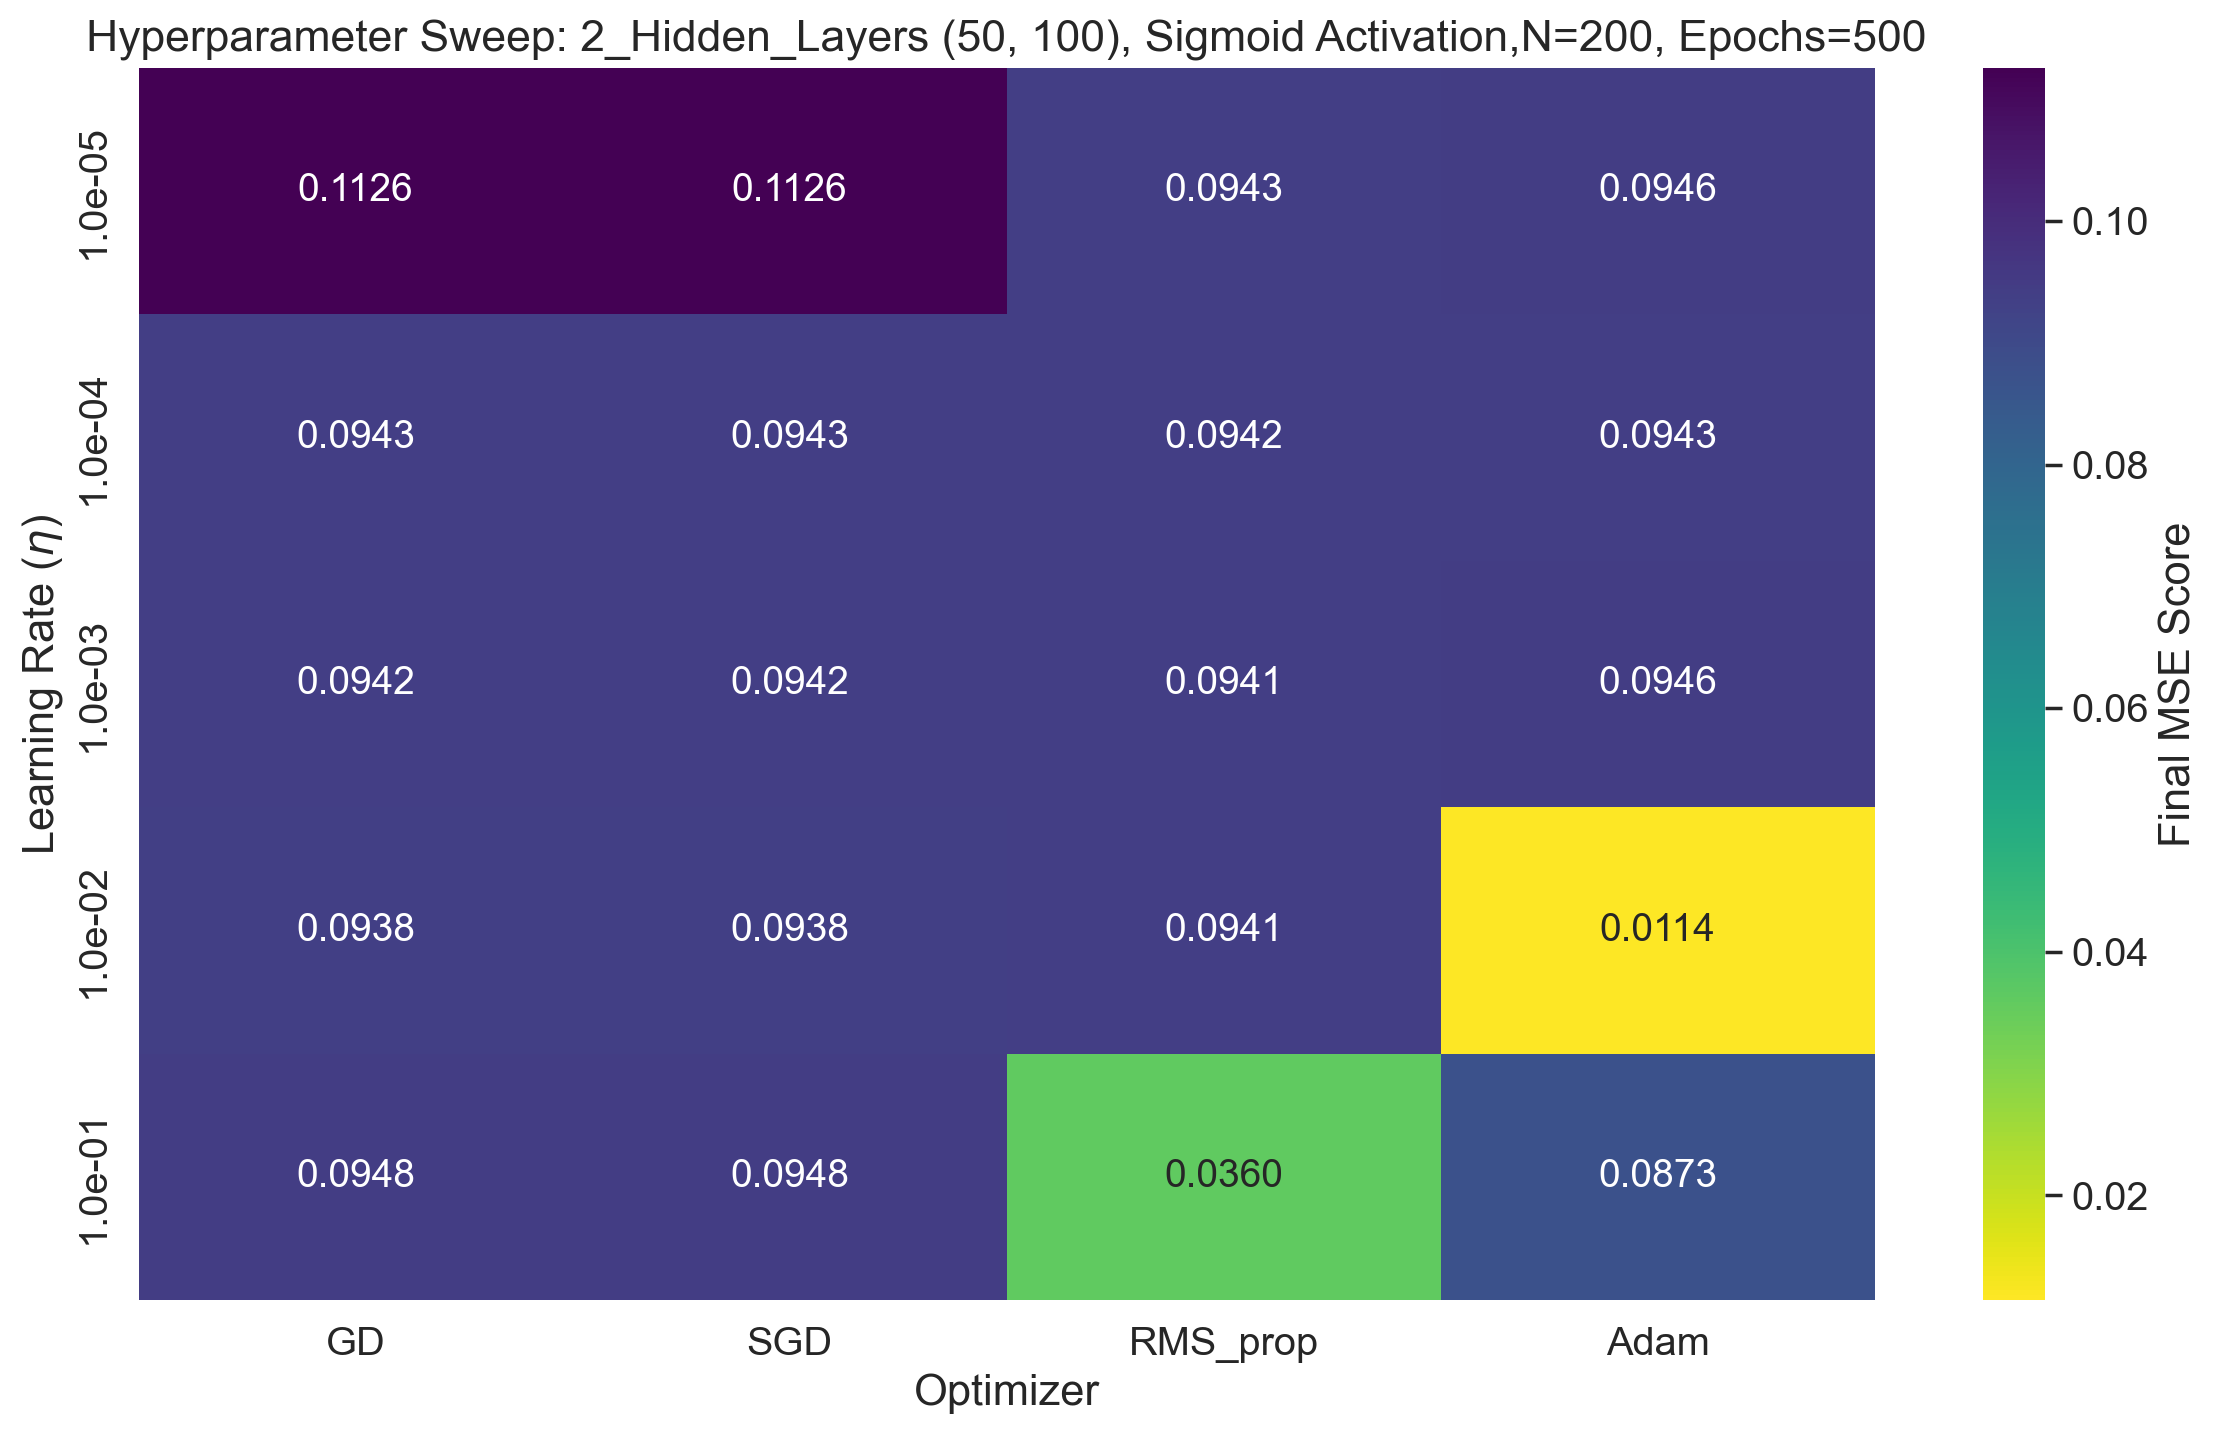

In [5]:
# Generate heatmaps for each layer architecture
for arch_name, sweep_data in all_sweep_results.items():
    plot_sweep_heatmap(sweep_data, eta_vals, arch_name,N, epochs_sweep)

# Part c
### Testing against Scikit-learn's library 

In [6]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

eta_val = 1e-1

mlp_regressor = MLPRegressor(
    # Architecture: Two hidden layers with 50 and 100 nodes
    hidden_layer_sizes=(hidden_nodes1, hidden_nodes2),
    # Hidden Layer Activation: Using sigmoid 
    activation='logistic', # 'logistic' is the string for sigmoid in Scikit-learn
    # L2 Regularization parameter (alpha corresponds to lambda)
    alpha=lam,
    # Optimizer
    solver='sgd',
    # Initial Learning Rate
    learning_rate_init=eta_val,
    # Max Epochs
    max_iter=1000,
    # Seed
    random_state=42
)



In [7]:
# y_train is raveled to ensure Scikit-Learn compatibility for regression
mlp_regressor.fit(X_train_scaled, y_train.ravel())


# Predict on fixed test set
y_pred_skl = mlp_regressor.predict(X_fixed_test_scaled)


skl_optimizers = {
    'SGD': 'sgd',
    'Adam': 'adam'
}


architectures_to_sweep = {
    '1_Hidden_Layer (50)': layer_sizes_1H,
    '2_Hidden_Layers (50, 100)': layer_sizes_2H
}


skl_sweep_results = {}

# Hyperparameter sweep for Scikit-Learn MLPRegressor
# Iterate over architectures
for arch_name, layer_sizes in architectures_to_sweep.items():
    hidden_layer_arch = layer_sizes[:-1]
    arch_scores = {}
    print(f"\n================ SKL Sweep for Architecture: {arch_name} ================")

    # Iterate over optimizers
    for opt_name, solver_type in skl_optimizers.items():
        print(f"--- Running {opt_name} ---")
        mse_scores_for_eta = [] # List to store MSE for each eta value

        # Iterate over eta values
        for eta in eta_vals:
            
            # Initialize MLPRegressor model for the current combination
            skl_model = MLPRegressor(
                
                hidden_layer_sizes=hidden_layer_arch, 
                
                # Configuration matching the custom FFNN regression model:
                activation='logistic',       # Sigmoid activation 
                alpha=lam,                   # L2 regularization (lambda)
                solver=solver_type,          # Optimizer (sgd or adam)
                learning_rate_init=eta,      # Learning rate (eta)
                max_iter=epochs_sweep,         # Max epochs
                random_state=42,             # Seed
            )

            # Train the model
            # y_train is raveled to ensure Scikit-Learn compatibility for regression
            skl_model.fit(X_train_scaled, y_train.ravel()) 

            # Predict on fixed test set
            y_pred_skl = skl_model.predict(X_fixed_test_scaled)
            final_mse = mean_squared_error(y_fixed_test.ravel(), y_pred_skl.ravel())
            mse_scores_for_eta.append(final_mse)

            print(f"  {opt_name} (eta={eta:.1e}): Test MSE={final_mse:.6f}")

        # Store the list of scores for the current optimizer under the current architecture
        arch_scores[opt_name] = mse_scores_for_eta

    # Store all optimizer results for the current architecture
    skl_sweep_results[arch_name] = arch_scores




================ SKL Sweep for Architecture: 1_Hidden_Layer (50) ================
--- Running SGD ---
  SGD (eta=1.0e-05): Test MSE=0.178407
  SGD (eta=1.0e-04): Test MSE=0.102238
  SGD (eta=1.0e-03): Test MSE=0.094834
  SGD (eta=1.0e-02): Test MSE=0.093928
  SGD (eta=1.0e-01): Test MSE=0.272404
--- Running Adam ---
  Adam (eta=1.0e-05): Test MSE=0.213133
  Adam (eta=1.0e-04): Test MSE=0.101408
  Adam (eta=1.0e-03): Test MSE=0.095978
  Adam (eta=1.0e-02): Test MSE=0.096510
  Adam (eta=1.0e-01): Test MSE=0.187989

================ SKL Sweep for Architecture: 2_Hidden_Layers (50, 100) ================
--- Running SGD ---
  SGD (eta=1.0e-05): Test MSE=0.137778
  SGD (eta=1.0e-04): Test MSE=0.096765
  SGD (eta=1.0e-03): Test MSE=0.095092
  SGD (eta=1.0e-02): Test MSE=0.094149
  SGD (eta=1.0e-01): Test MSE=0.095044
--- Running Adam ---
  Adam (eta=1.0e-05): Test MSE=0.120729
  Adam (eta=1.0e-04): Test MSE=0.093861
  Adam (eta=1.0e-03): Test MSE=0.102025
  Adam (eta=1.0e-02): Test MSE=0.095

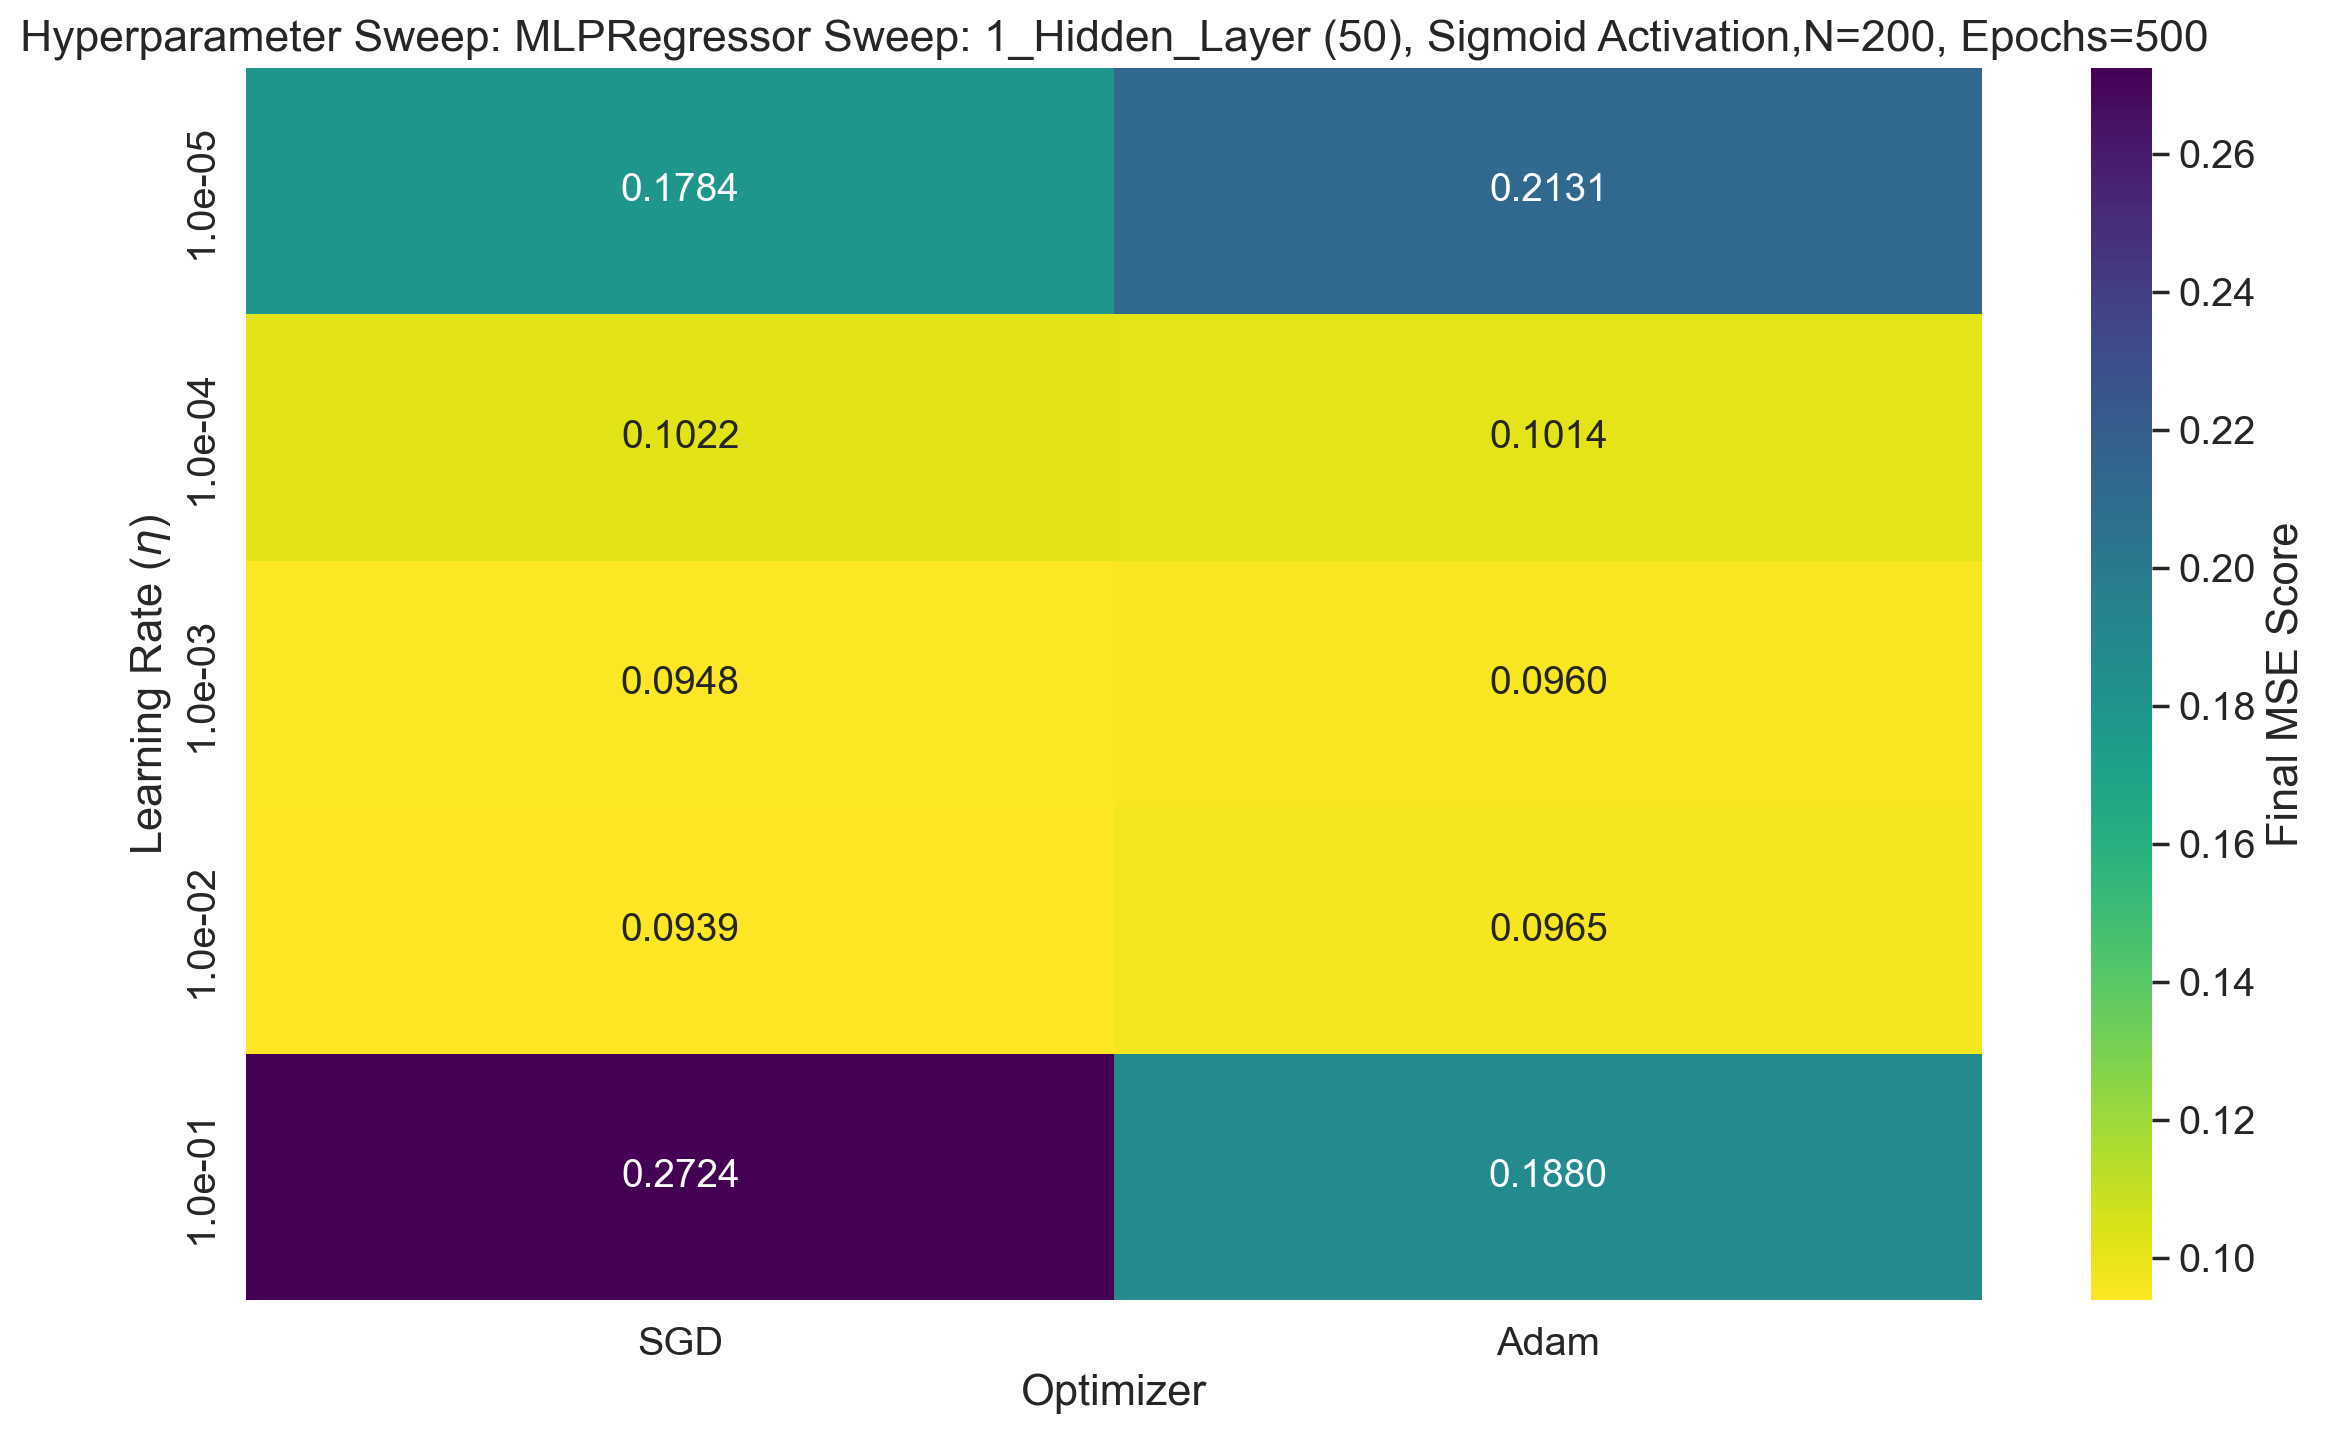

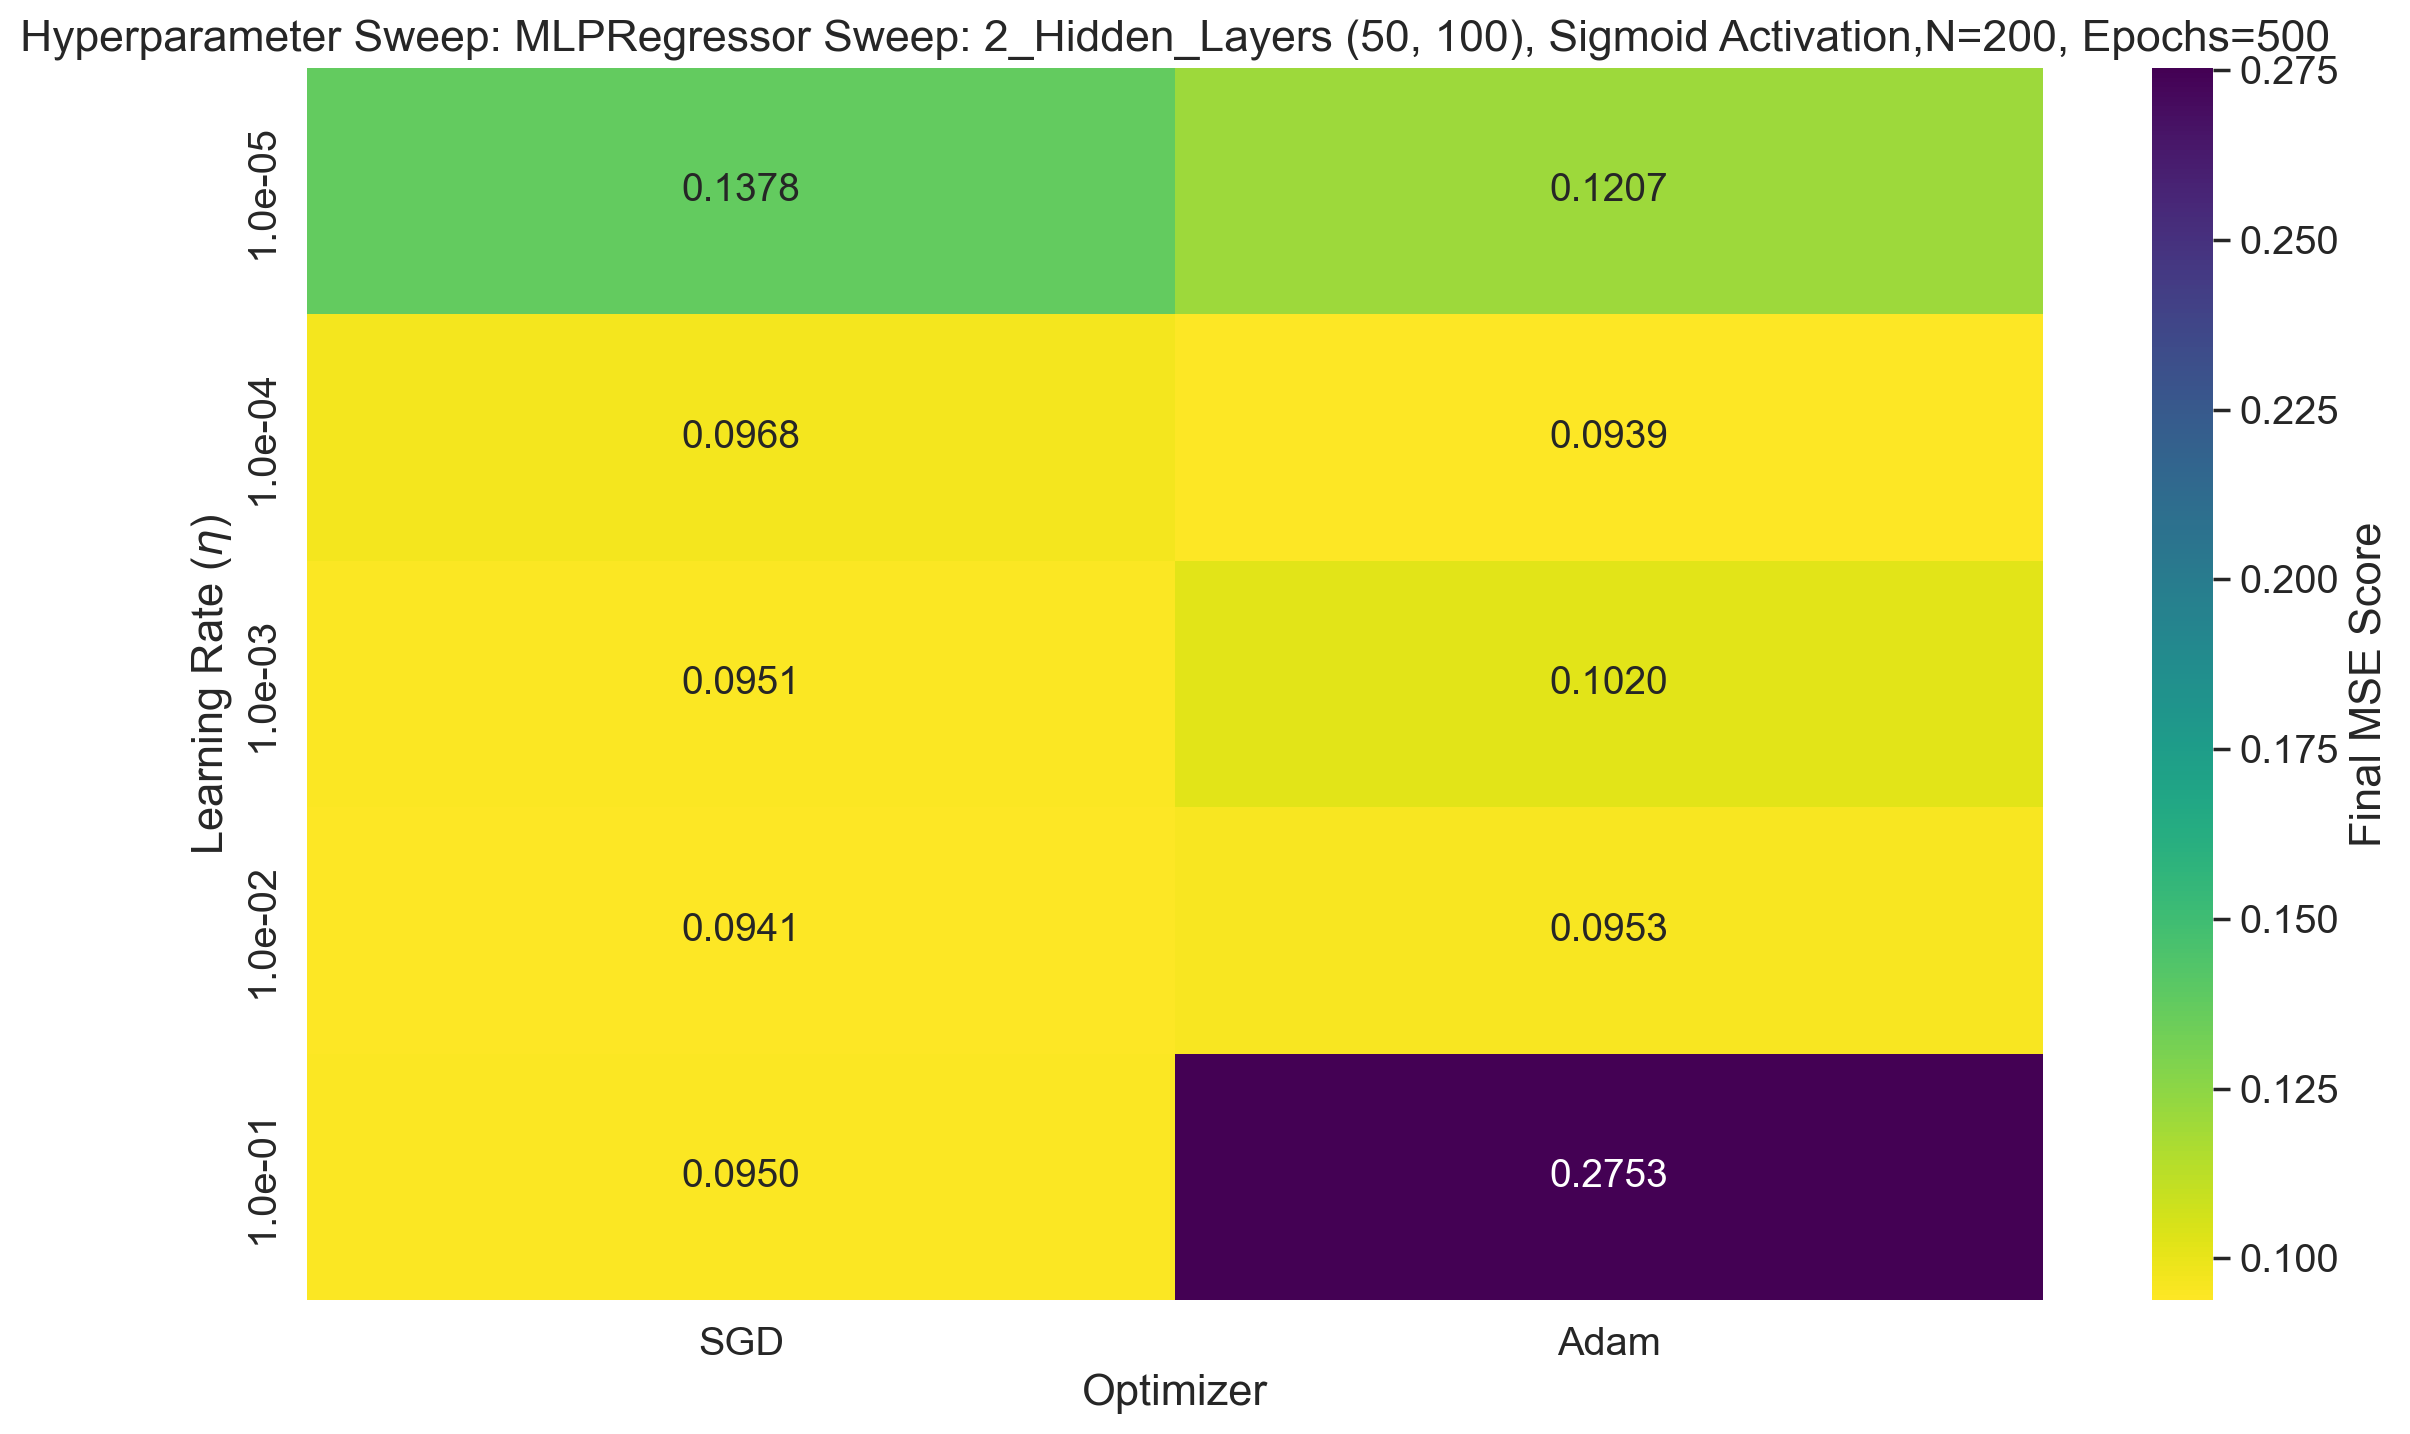

In [8]:

for arch_name, sweep_data in skl_sweep_results.items():
    plot_sweep_heatmap(sweep_data, eta_vals, f"MLPRegressor Sweep: {arch_name}",N, epochs_sweep)



### Autograd check
Check if our parameters are correct

In [9]:
#Recreate X_batch and t_batch in FFNN from earlier for autograd check

batch_size_test = min(32, X_fixed_test_scaled.shape[0])
n_test = X_fixed_test_scaled.shape[0]

if n_test == 0:
    raise ValueError("No test samples available.")

# If batch == full test set, just take all of it
if batch_size_test == n_test:
    start_index = 0
else:
    # high is exclusive; allow the last valid start
    start_index = np.random.randint(0, n_test - batch_size_test + 1)

end_index = start_index + batch_size_test
X_batch = X_fixed_test_scaled[start_index:end_index]

# Create mini-batch
X_batch = X_fixed_test_scaled[start_index:end_index]
t_batch = y_fixed_test[start_index:end_index]

# Use the previously defined FFNN 
manual_grads = nn.compute_gradient(X_batch, t_batch)

# Compute gradients using autograd
autograd_grads = nn.autograd_gradient(X_batch, t_batch)

# Compare gradients layer by layer
for i in range(len(nn.layers)):
    # Separate Weight gradients (index 0) and Bias gradients (index 1)
    manual_W_g, manual_b_g = manual_grads[i]
    autograd_W_g, autograd_b_g = autograd_grads[i]

    # Compare the arrays individually using np.allclose
    weights_match = np.allclose(manual_W_g, autograd_W_g)
    biases_match = np.allclose(manual_b_g, autograd_b_g)

    print(f"Layer {i}: Weights match: {weights_match}, Biases match: {biases_match}")

print(X_batch.shape, t_batch.shape)
print("any NaN in X?", np.isnan(X_batch).any(), " any NaN in t?", np.isnan(t_batch).any())


Layer 0: Weights match: True, Biases match: True
Layer 1: Weights match: True, Biases match: True
Layer 2: Weights match: True, Biases match: True
(32, 1) (32, 1)
any NaN in X? False  any NaN in t? False


Get y_pred for final plot

In [11]:
input_dim = X_train_scaled.shape[1]
opt_name = "RMS_prop"
eta = 1e-3
act_name = "Sigmoid"
layer_sizes = layer_sizes_2H

y_pred_b = train_eval_once_with_pred(opt_name, eta,
    X_train_scaled, y_train,
    X_fixed_test_scaled, y_fixed_test,
    input_dim, layer_sizes, act_name,
    epochs=500, batches=32,
    l1=0.0, l2=0.0, lam=0.0,
)





In [31]:
import numpy as np

x_plot = np.linspace(-1, 1, 500).reshape(-1, 1)
x_plot_scaled = scaler.transform(x_plot)

np.save("x_plot.npy", x_plot_scaled)



In [ ]:

# retrain best model from scratch and save predictions
nn_b = FFNN(
    network_input_size= 1,
    layer_output_sizes=layer_sizes_2H,
    activation_funcs=[sigmoid, sigmoid, identity],
    activation_ders=[derivate(sigmoid), derivate(sigmoid),derivate(identity)],
    cost_fun=CostOLS,
    cost_der=dCostOLS,
    seed=42
)
scheduler = RMS_prop(eta=1e-3, rho=rho_val)
nn_b.fit(
    X_train_scaled,
    y_train,
    scheduler=scheduler,
    batches=32,
    epochs=500,
    lam=0.0
)
y_true = runge_function(x_plot).ravel()

y_pred_b = nn_b.predict(x_plot_scaled).ravel()  
np.save("b_y_pred_nn.npy", y_pred_b)



In [57]:
x_plot = np.linspace(-1, 1, 500).reshape(-1, 1)
x_plot_scaled = scaler.transform(x_plot)

y_pred_b = nn_b.predict(x_plot_scaled)
print("raw pred shape:", y_pred_b.shape)  # now (500, 1) or (500,)
y_pred_b = y_pred_b.ravel()

y_true = runge_function(x_plot).ravel()

raw pred shape: (500, 1)


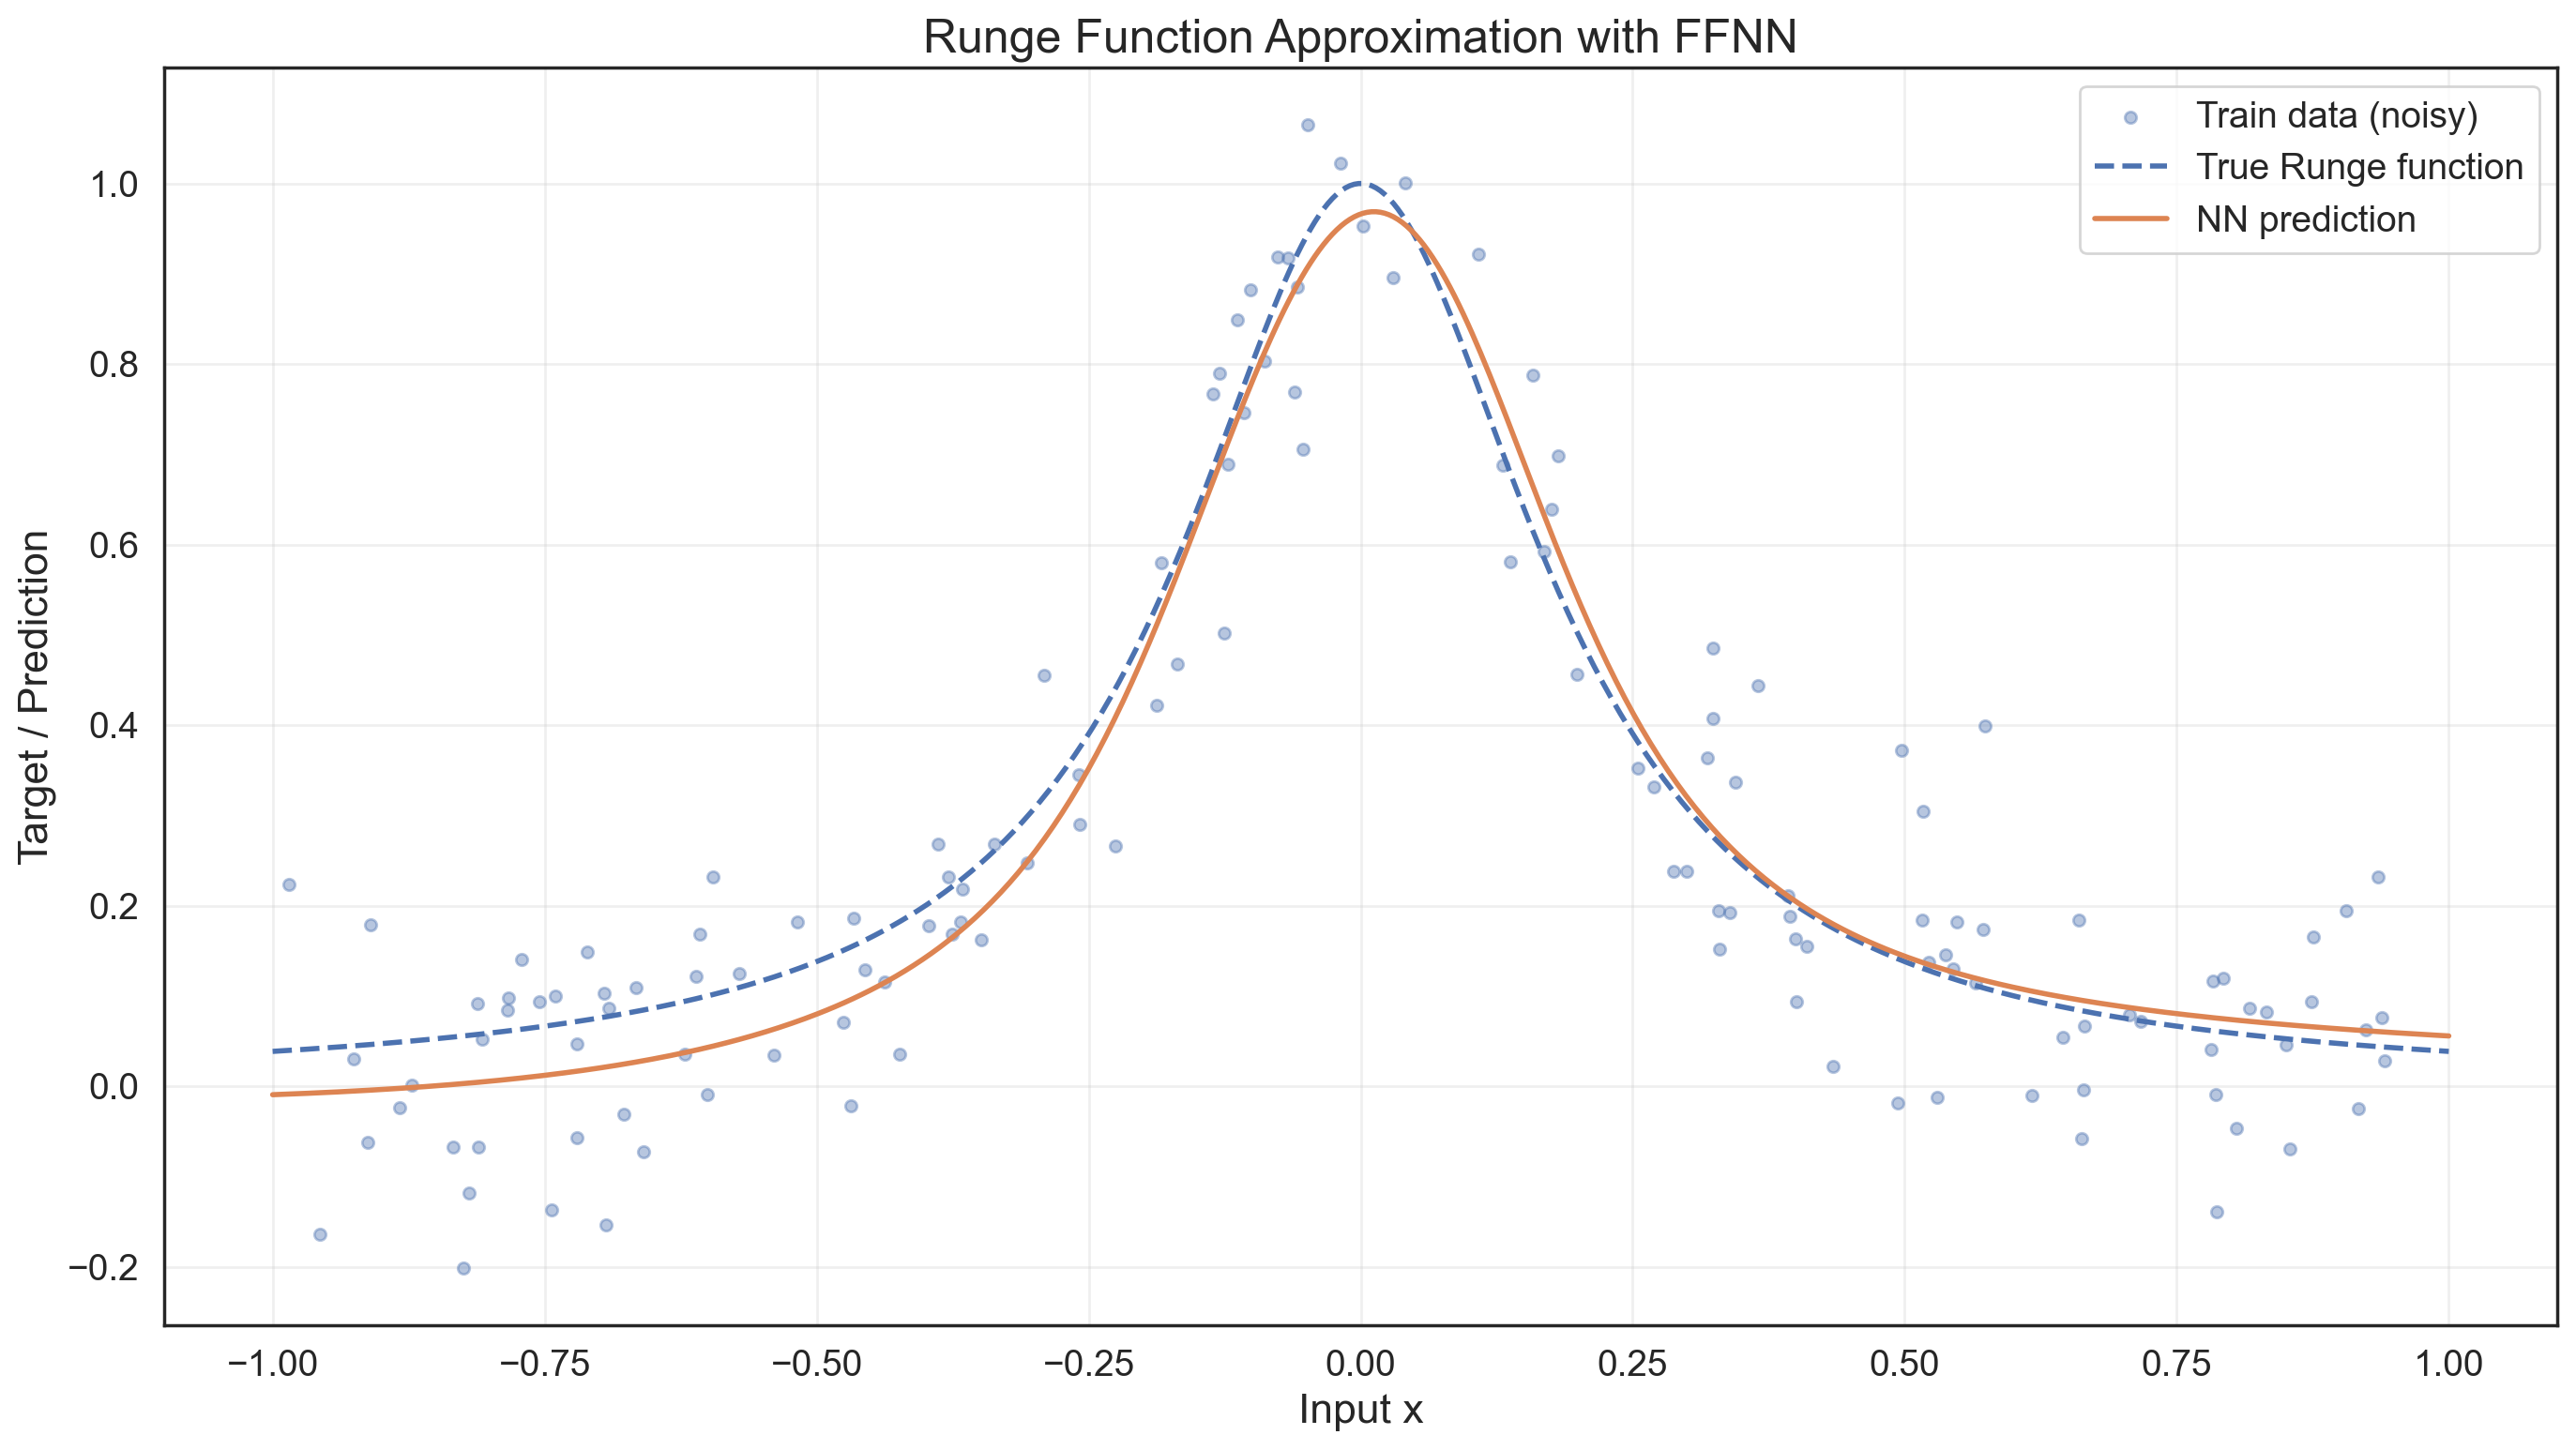

In [ ]:


plt.figure(figsize=(14, 8))

plt.scatter(
    X_train,
    y_train,
    s=20,
    alpha=0.4,
    label="Train data (noisy)"
)

plt.plot(
    x_plot,
    y_true,
    linestyle="--",
    linewidth=2,
    label="True Runge function"
)

plt.plot(
    x_plot,
    y_pred_b,
    linewidth=2,
    label="NN prediction"
)

# Axis labels
plt.xlabel("Input x", fontsize=16)
plt.ylabel("Target / Prediction", fontsize=16)

# Title
plt.title("Runge Function Approximation with FFNN", fontsize=18)

# Ticks
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Legend
plt.legend(fontsize=14, loc="best")

# Grid
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()
